In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("shades.csv")
print(df.columns.tolist())
print(df.head())

['brand', 'brand_short', 'product', 'product_short', 'hex', 'H', 'S', 'V', 'L', 'group']
        brand brand_short product product_short     hex     H     S     V   L  \
0  Maybelline          mb  Fit Me           fmf  f3cfb3  26.0  0.26  0.95  86   
1  Maybelline          mb  Fit Me           fmf  ffe3c2  32.0  0.24  1.00  92   
2  Maybelline          mb  Fit Me           fmf  ffe0cd  23.0  0.20  1.00  91   
3  Maybelline          mb  Fit Me           fmf  ffd3be  19.0  0.25  1.00  88   
4  Maybelline          mb  Fit Me           fmf  bd9584  18.0  0.30  0.74  65   

   group  
0      2  
1      2  
2      2  
3      2  
4      2  


In [3]:
group_labels = {
    0: "Fenty Beauty",
    1: "Make Up For Ever",
    2: "US Best Sellers",
    3: "BIPOC-reccommended, BIPOC Founders",
    4: "BIPOC-reccommended, White Founders",
    5: "Nigerian Best Sellers",
    6: "Japanese Best Sellers",
    7: "Indian Best Sellers",
}
df["group_label"] = df["group"].map(group_labels)

In [4]:
brand_shade_count = df.groupby("brand")["L"].transform("count")
df["shade_count"] = brand_shade_count
df["shade_rank"] = df.groupby("brand")["L"].rank(pct=True)

In [5]:
tertiles = df["L"].quantile([1/3, 2/3])
df["is_deep_shade"] = (df["L"] <= tertiles.iloc[0]).astype(int)
print(df["is_deep_shade"].value_counts(normalize=True))

is_deep_shade
0    0.6656
1    0.3344
Name: proportion, dtype: float64


In [6]:
X = pd.get_dummies (df[["group_label", "shade_count", "shade_rank"]], 
                    columns = ["group_label"], 
                    drop_first = True)
y = df["is_deep_shade"]
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.25, random_state = 42, stratify=y)

In [7]:
baseline_pred = np.full_like(y_test, y_train.mode()[0])
print("Baseline accuracy:", accuracy_score(y_test, baseline_pred))

Baseline accuracy: 0.6624203821656051


In [8]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)

print("\n--- Logistic Regression ---")
print("Accuracy:", precision_score(y_test, logreg_pred))
print("Precision:", precision_score(y_test, logreg_pred))
print("Recall:", recall_score(y_test, logreg_pred))
print("F1 Score:", f1_score(y_test, logreg_pred))
print(confusion_matrix(y_test, logreg_pred))


--- Logistic Regression ---
Accuracy: 0.875
Precision: 0.875
Recall: 0.7924528301886793
F1 Score: 0.8316831683168316
[[98  6]
 [11 42]]


In [9]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("\n---Random Forest ---")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)
print("\nFeature Importance:")


---Random Forest ---
Accuracy: 0.910828025477707
Precision: 0.8679245283018868
Recall: 0.8679245283018868
F1 Score: 0.8679245283018868
[[97  7]
 [ 7 46]]

Feature Importance:


In [10]:
cv_scores_lr = cross_val_score(logreg, X, y, cv=5, scoring="f1")
cv_scores_rf = cross_val_score(rf, X, y, cv=5, scoring="f1")
print("\nLogisitc Regression 5-fold F1:", cv_scores_lr.mean())
print("Random Forest 5-fold F1:", cv_scores_rf.mean())


Logisitc Regression 5-fold F1: 0.5990836981879774
Random Forest 5-fold F1: 0.62828545580331


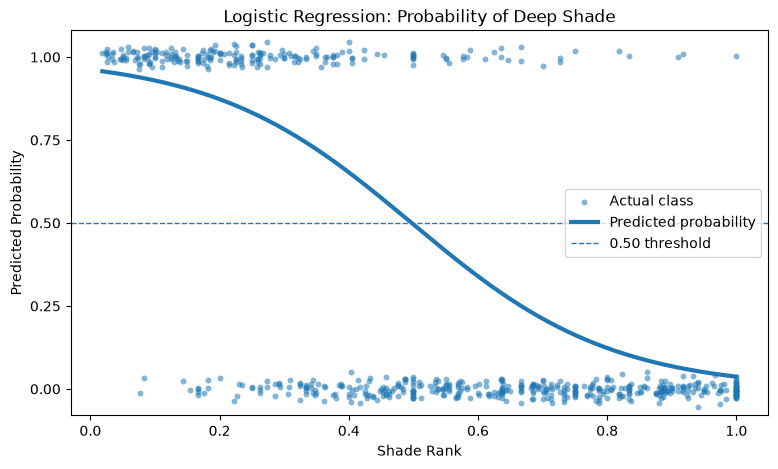

In [11]:
shade_values = np.linspace(X["shade_rank"].min(), X["shade_rank"].max(), 200)

X_curve = pd.DataFrame(
    np.tile(X.median().to_numpy(), (len(shade_values), 1)),
    columns=X.columns
)
X_curve["shade_rank"] = shade_values

probabilities = logreg.predict_proba(X_curve)[:, 1]

rng = np.random.default_rng(42)
jitter = rng.normal(0, 0.018, size=len(y))
y_plot = y.to_numpy() + jitter

plt.figure(figsize=(9, 5))
plt.scatter(
    X["shade_rank"],
    y_plot,
    s=18,
    alpha=0.55,
    linewidths=0,
    label="Actual class"
)
plt.plot(shade_values, probabilities, linewidth=3, label="Predicted probability")
plt.axhline(0.5, linestyle="--", linewidth=1, label="0.50 threshold")
plt.title("Logistic Regression: Probability of Deep Shade")
plt.xlabel("Shade Rank")
plt.ylabel("Predicted Probability")
plt.ylim(-0.08, 1.08)
plt.yticks([0, 0.25, 0.5, 0.75, 1.0])
plt.legend()
plt.show()



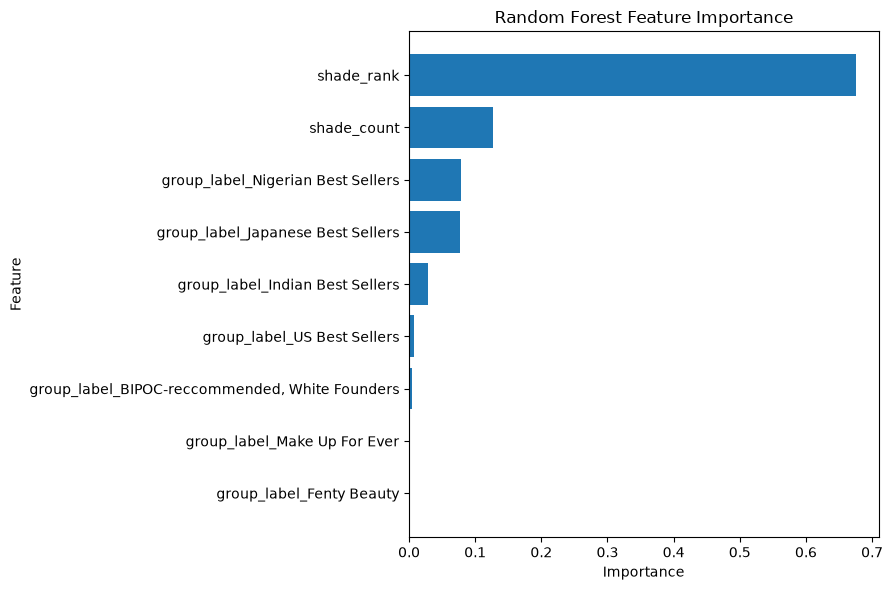

In [14]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd

forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42
)

forest.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()